# Grid Search — Baseline ResNet18

Systematic hyperparameter search over Phase 2 fine-tuning parameters for the baseline ResNet18 model under **3-fold stratified cross-validation**. Phase 1 is fixed based on prior validation that lr=1e-3 with no weight decay converges cleanly with the frozen backbone. Results are saved to CSV after every individual fold so the search can be safely interrupted and resumed without losing progress.

Two successive grid searches were run over different LR/weight-decay regions:

**V1 — low-LR pilot (9 configs × 3 folds = 27 runs):**
- Phase 2 LR: `{1e-5, 5e-6, 1e-6}` — starting from previous fine-tune rate and decreasing
- Weight decay: `{0, 1e-4, 1e-3}` — no / light / moderate AdamW regularisation
- Output: `grid_search_results.csv`

**V2 — higher-LR follow-up (9 configs × 3 folds = 27 runs):**
- Phase 2 LR: `{5e-4, 1e-4, 5e-5}` — shifted up after V1 showed stronger LR needed
- Weight decay: `{1e-4, 1e-3, 1e-2}` — shifted to include more aggressive 1e-2
- Output: `grid_search_results_v2.csv`

**Fixed parameters (not searched):**
- Phase 1 LR: `1e-3`, weight decay: `0`, optimiser: AdamW, criterion: BCEWithLogitsLoss
- Batch size: 32, Phase 1 epochs: 20 (ceiling), Phase 2 epochs: 15 (ceiling)
- Early stopping patience: P1=4, P2=3; Architecture: base ResNet18, MLP head

**Selection criterion:** highest mean val accuracy across 3 folds. Ties broken by lowest mean val loss, then fewest Phase 2 epochs (via early stopping), then lowest weight decay.

## 1 - Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" /  "grid-search-results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Results dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\grid-search-results


In [2]:
import itertools
import csv
import os
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score

import src.scripts.data    as data
import src.scripts.models  as models
import src.scripts.trainer as trainer
import src.scripts.utils   as utils

utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## 2 Data Preparation

The 80/20 stratified outer split uses the same seed as all other notebooks so that the held-out test set is identical across all stages. Both grid searches operate exclusively within `X_trainval / y_trainval`.

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

# Outer split — fixed seed 42, never changes across stages
X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nGrid search operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used at any point in this notebook.")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

Grid search operates on 1321 train+val samples.
Held-out test set is NOT used at any point in this notebook.


## 3 Grid Definitions

In [4]:
# Initial Pilot Testing hyperparameters informing grid search ranges:
# Phase 1:
    # "num_epochs": 15,
    # "lr": 1e-3,
# Phase 2:
    # "num_epochs": 10
    # "lr": 1e-5


# Shared fixed parameters
LR_PHASE1   = 1e-3   # validated by prior tracking curves
WD_PHASE1   = 0      # head regularisation handled by Dropout(0.3)
N_SPLITS    = 3      # 3-fold for grid search
BATCH_SIZE  = 32
P1_EPOCHS   = 20     # ceiling; early stopping applies
P2_EPOCHS   = 15     # ceiling; early stopping applies
P1_PATIENCE = 4
P2_PATIENCE = 3
SEED        = 42

CSV_FIELDNAMES = [
    "lr_phase1", "wd_phase1", "lr_phase2", "weight_decay",
    "fold", "val_acc", "val_loss", "val_f1",
    "p1_epochs_run", "p2_epochs_run",
    "timestamp", "error"
]

# V1 grid — low-LR initial search
GRID_V1 = {
    "lr_phase2"    : [1e-5, 5e-6, 1e-6],
    "weight_decay" : [0, 1e-4, 1e-3],
}
RESULTS_FILE_V1 = RESULTS_DIR / "grid_search_results.csv"

# V2 grid — higher-LR follow-up
GRID_V2 = {
    "lr_phase2"    : [5e-4, 1e-4, 5e-5],
    "weight_decay" : [1e-4, 1e-3, 1e-2],
}
RESULTS_FILE_V2 = RESULTS_DIR / "grid_search_results_v2.csv"

print(f"V1: {len(list(itertools.product(*GRID_V1.values())))} configs × {N_SPLITS} folds = "
      f"{len(list(itertools.product(*GRID_V1.values()))) * N_SPLITS} runs → {RESULTS_FILE_V1.name}")
print(f"V2: {len(list(itertools.product(*GRID_V2.values())))} configs × {N_SPLITS} folds = "
      f"{len(list(itertools.product(*GRID_V2.values()))) * N_SPLITS} runs → {RESULTS_FILE_V2.name}")

V1: 9 configs × 3 folds = 27 runs → grid_search_results.csv
V2: 9 configs × 3 folds = 27 runs → grid_search_results_v2.csv


In [5]:
def run_grid_search(grid, results_file, label=""):
    """Execute a grid search, saving every fold result to results_file."""
    all_combos    = list(itertools.product(grid["lr_phase2"], grid["weight_decay"]))
    total_runs    = len(all_combos) * N_SPLITS
    completed = utils.load_completed_runs(results_file, [("lr_phase2", float), ("weight_decay", float), ("fold", int)])
    run_number    = len(completed)

    print(f"\n{'='*65}")
    print(f"  {label}  |  {len(all_combos)} configs × {N_SPLITS} folds = {total_runs} runs")
    print(f"  Output : {results_file.name}")
    print(f"  Already completed: {run_number} runs")
    print(f"{'='*65}")

    for lr_p2, wd in all_combos:
        for fold_idx in range(N_SPLITS):
            run_key = (lr_p2, wd, fold_idx)

            if run_key in completed:
                print(f"SKIP  lr2={lr_p2:.0e}  wd={wd:.0e}  fold={fold_idx+1}/{N_SPLITS}")
                continue

            utils.set_seed(SEED)
            run_number += 1
            print(f"\n{'='*65}")
            print(f"  [{label}] Run {run_number}/{total_runs}  |  "
                  f"lr2={lr_p2:.0e}  wd={wd:.0e}  fold={fold_idx+1}/{N_SPLITS}")
            print(f"{'='*65}")

            try:
                train_loader, val_loader = data.get_fold_loaders(
                    X_trainval, y_trainval,
                    fold_idx=fold_idx,
                    train_transform=train_transform,
                    test_transform=test_transform,
                    n_splits=N_SPLITS,
                    batch_size=BATCH_SIZE,
                    SEED=SEED
                )

                model = models.get_model(architecture="base", head="mlp")

                run_configs = {
                    "phase1": {
                        "num_epochs"  : P1_EPOCHS,
                        "lr"          : LR_PHASE1,
                        "parameters"  : "head_and_attention",
                        "optimiser"   : optim.AdamW,
                        "criterion"   : nn.BCEWithLogitsLoss(),
                        "weight_decay": WD_PHASE1,
                    },
                    "phase2": {
                        "num_epochs"  : P2_EPOCHS,
                        "lr"          : lr_p2,
                        "parameters"  : "all",
                        "optimiser"   : optim.AdamW,
                        "criterion"   : nn.BCEWithLogitsLoss(),
                        "weight_decay": wd,
                    },
                }

                _, _, _, val_accs_p1 = trainer.train_model(
                    model, train_loader, val_loader,
                    config_name="phase1",
                    train_configs=run_configs,
                    early_stopping_patience=P1_PATIENCE
                )
                p1_epochs_run = len(val_accs_p1)

                _, _, val_losses_p2, val_accs_p2 = trainer.train_model(
                    model, train_loader, val_loader,
                    config_name="phase2",
                    train_configs=run_configs,
                    early_stopping_patience=P2_PATIENCE
                )
                p2_epochs_run = len(val_accs_p2)

                model.eval()
                all_preds, all_labels_list = [], []
                with torch.no_grad():
                    for imgs, lbls in val_loader:
                        imgs   = imgs.to(next(model.parameters()).device)
                        logits = model(imgs).squeeze(1)
                        preds  = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
                        all_preds.extend(preds)
                        all_labels_list.extend(lbls.tolist())
                val_f1 = f1_score(all_labels_list, all_preds, average="binary", zero_division=0)

                result_row = {
                    "lr_phase1"    : LR_PHASE1,
                    "wd_phase1"    : WD_PHASE1,
                    "lr_phase2"    : lr_p2,
                    "weight_decay" : wd,
                    "fold"         : fold_idx,
                    "val_acc"      : round(float(val_accs_p2[-1]),  6),
                    "val_loss"     : round(float(val_losses_p2[-1]), 6),
                    "val_f1"       : round(float(val_f1), 6),
                    "p1_epochs_run": p1_epochs_run,
                    "p2_epochs_run": p2_epochs_run,
                    "timestamp"    : datetime.now().isoformat(timespec="seconds"),
                    "error"        : "",
                }
                utils.append_result(results_file, CSV_FIELDNAMES, result_row)
                completed.add(run_key)

                print(f"val_acc={val_accs_p2[-1]:.4f}  "
                      f"val_f1={val_f1:.4f}  "
                      f"val_loss={val_losses_p2[-1]:.4f}  "
                      f"(p1={p1_epochs_run}ep  p2={p2_epochs_run}ep)")

            except Exception as e:
                error_msg = f"{type(e).__name__}: {str(e)}"
                print(f"ERROR -- {error_msg}")
                traceback.print_exc()
                error_row = {
                    "lr_phase1" : LR_PHASE1, "wd_phase1" : WD_PHASE1,
                    "lr_phase2" : lr_p2,     "weight_decay": wd,
                    "fold"      : fold_idx,
                    "val_acc"   : "", "val_loss": "", "val_f1": "",
                    "p1_epochs_run": "", "p2_epochs_run": "",
                    "timestamp" : datetime.now().isoformat(timespec="seconds"),
                    "error"     : error_msg,
                }
                utils.append_result(results_file, CSV_FIELDNAMES, error_row)

    print(f"\n{'='*65}")
    print(f"  {label} COMPLETE — results saved to: {results_file}")
    print(f"{'='*65}")

## 4 Grid Search Loops

Run V1 first, then V2. Each loop is independently resumable — re-running a cell skips already-completed folds. Expected duration: ~20 min/run → ~18 hours total across both searches.

### 4a - V1: Low-LR pilot (`grid_search_results.csv`)

In [6]:
run_grid_search(GRID_V1, RESULTS_FILE_V1, label="V1 (low-LR pilot)")


  V1 (low-LR pilot)  |  9 configs × 3 folds = 27 runs
  Output : grid_search_results.csv
  Already completed: 27 runs
SKIP  lr2=1e-05  wd=0e+00  fold=1/3
SKIP  lr2=1e-05  wd=0e+00  fold=2/3
SKIP  lr2=1e-05  wd=0e+00  fold=3/3
SKIP  lr2=1e-05  wd=1e-04  fold=1/3
SKIP  lr2=1e-05  wd=1e-04  fold=2/3
SKIP  lr2=1e-05  wd=1e-04  fold=3/3
SKIP  lr2=1e-05  wd=1e-03  fold=1/3
SKIP  lr2=1e-05  wd=1e-03  fold=2/3
SKIP  lr2=1e-05  wd=1e-03  fold=3/3
SKIP  lr2=5e-06  wd=0e+00  fold=1/3
SKIP  lr2=5e-06  wd=0e+00  fold=2/3
SKIP  lr2=5e-06  wd=0e+00  fold=3/3
SKIP  lr2=5e-06  wd=1e-04  fold=1/3
SKIP  lr2=5e-06  wd=1e-04  fold=2/3
SKIP  lr2=5e-06  wd=1e-04  fold=3/3
SKIP  lr2=5e-06  wd=1e-03  fold=1/3
SKIP  lr2=5e-06  wd=1e-03  fold=2/3
SKIP  lr2=5e-06  wd=1e-03  fold=3/3
SKIP  lr2=1e-06  wd=0e+00  fold=1/3
SKIP  lr2=1e-06  wd=0e+00  fold=2/3
SKIP  lr2=1e-06  wd=0e+00  fold=3/3
SKIP  lr2=1e-06  wd=1e-04  fold=1/3
SKIP  lr2=1e-06  wd=1e-04  fold=2/3
SKIP  lr2=1e-06  wd=1e-04  fold=3/3
SKIP  lr2=1e-06  

### 4b - V2: Higher-LR follow-up (`grid_search_results_v2.csv`)

In [7]:
run_grid_search(GRID_V2, RESULTS_FILE_V2, label="V2 (higher-LR follow-up)")


  V2 (higher-LR follow-up)  |  9 configs × 3 folds = 27 runs
  Output : grid_search_results_v2.csv
  Already completed: 27 runs
SKIP  lr2=5e-04  wd=1e-04  fold=1/3
SKIP  lr2=5e-04  wd=1e-04  fold=2/3
SKIP  lr2=5e-04  wd=1e-04  fold=3/3
SKIP  lr2=5e-04  wd=1e-03  fold=1/3
SKIP  lr2=5e-04  wd=1e-03  fold=2/3
SKIP  lr2=5e-04  wd=1e-03  fold=3/3
SKIP  lr2=5e-04  wd=1e-02  fold=1/3
SKIP  lr2=5e-04  wd=1e-02  fold=2/3
SKIP  lr2=5e-04  wd=1e-02  fold=3/3
SKIP  lr2=1e-04  wd=1e-04  fold=1/3
SKIP  lr2=1e-04  wd=1e-04  fold=2/3
SKIP  lr2=1e-04  wd=1e-04  fold=3/3
SKIP  lr2=1e-04  wd=1e-03  fold=1/3
SKIP  lr2=1e-04  wd=1e-03  fold=2/3
SKIP  lr2=1e-04  wd=1e-03  fold=3/3
SKIP  lr2=1e-04  wd=1e-02  fold=1/3
SKIP  lr2=1e-04  wd=1e-02  fold=2/3
SKIP  lr2=1e-04  wd=1e-02  fold=3/3
SKIP  lr2=5e-05  wd=1e-04  fold=1/3
SKIP  lr2=5e-05  wd=1e-04  fold=2/3
SKIP  lr2=5e-05  wd=1e-04  fold=3/3
SKIP  lr2=5e-05  wd=1e-03  fold=1/3
SKIP  lr2=5e-05  wd=1e-03  fold=2/3
SKIP  lr2=5e-05  wd=1e-03  fold=3/3
SKIP  l

## 5 Combined Results Analysis

Loads both CSVs, tags each row with its search version, and produces the full combined summary table plus the overall winning configuration.

In [8]:
dfs = []
for path, label in [(RESULTS_FILE_V1, "V1"), (RESULTS_FILE_V2, "V2")]:
    df = pd.read_csv(path)
    df["error"]   = df["error"].fillna("")
    df["version"] = label
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_ok  = df_all[df_all["error"] == ""].copy()
df_fail = df_all[df_all["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

total_v1 = len(list(itertools.product(*GRID_V1.values()))) * N_SPLITS
total_v2 = len(list(itertools.product(*GRID_V2.values()))) * N_SPLITS

ok_v1  = len(df_ok[df_ok["version"] == "V1"])
ok_v2  = len(df_ok[df_ok["version"] == "V2"])

print(f"V1 successful : {ok_v1} / {total_v1}")
print(f"V2 successful : {ok_v2} / {total_v2}")
print(f"Failed runs   : {len(df_fail)}")
if len(df_fail) > 0:
    print(df_fail[["version", "lr_phase2", "weight_decay", "fold", "error"]].to_string(index=False))

V1 successful : 27 / 27
V2 successful : 27 / 27
Failed runs   : 0


In [9]:
# Aggregate across folds — grouped by version + lr_phase2 + weight_decay
group_cols = ["version", "lr_phase2", "weight_decay"]

summary = (
    df_ok
    .groupby(group_cols)
    .agg(
        mean_val_f1   = ("val_f1",        "mean"),
        std_val_f1    = ("val_f1",        "std"),
        mean_val_acc  = ("val_acc",       "mean"),
        std_val_acc   = ("val_acc",       "std"),
        mean_val_loss = ("val_loss",      "mean"),
        std_val_loss  = ("val_loss",      "std"),
        mean_p2_epochs= ("p2_epochs_run", "mean"),
        n_folds       = ("val_f1",        "count"),
    )
    .reset_index()
    .sort_values(["mean_val_f1", "mean_val_loss"], ascending=[False, True])
)

summary["val_f1_display"]  = summary.apply(lambda r: f"{r.mean_val_f1:.4f} ± {r.std_val_f1:.4f}", axis=1)
summary["val_acc_display"] = summary.apply(lambda r: f"{r.mean_val_acc:.4f} ± {r.std_val_acc:.4f}", axis=1)
summary["val_loss_display"]= summary.apply(lambda r: f"{r.mean_val_loss:.4f} ± {r.std_val_loss:.4f}", axis=1)

display_cols = ["version", "lr_phase2", "weight_decay",
                "val_f1_display", "val_acc_display", "val_loss_display",
                "mean_p2_epochs", "n_folds"]

print("\nCombined results table (sorted by mean val F1):\n")
summary[display_cols]


Combined results table (sorted by mean val F1):



,version,lr_phase2,weight_decay,val_f1_display,val_acc_display,val_loss_display,mean_p2_epochs,n_folds
12,V2,0.000100,0.0001,0.9175 ± 0.0200,0.9379 ± 0.0130,0.2230 ± 0.0492,10.000000,3
13,V2,0.000100,0.0010,0.9107 ± 0.0075,0.9326 ± 0.0034,0.2193 ± 0.0092,7.666667,3
9,V2,0.000050,0.0001,0.9046 ± 0.0190,0.9281 ± 0.0131,0.2229 ± 0.0550,8.000000,3
11,V2,0.000050,0.0100,0.9037 ± 0.0304,0.9281 ± 0.0198,0.2407 ± 0.0578,9.000000,3
16,V2,0.000500,0.0010,0.9037 ± 0.0354,0.9303 ± 0.0228,0.3108 ± 0.1745,9.000000,3
15,V2,0.000500,0.0001,0.9002 ± 0.0159,0.9167 ± 0.0151,0.2292 ± 0.0653,9.000000,3
10,V2,0.000050,0.0010,0.9002 ± 0.0196,0.9251 ± 0.0120,0.2216 ± 0.0552,8.000000,3
14,V2,0.000100,0.0100,0.8924 ± 0.0208,0.9144 ± 0.0243,0.2707 ± 0.0342,7.000000,3
6,V1,0.000010,0.0000,0.8854 ± 0.0182,0.9114 ± 0.0202,0.2105 ± 0.0135,14.000000,3
7,V1,0.000010,0.0001,0.8854 ± 0.0182,0.9114 ± 0.0202,0.2105 ± 0.0135,14.000000,3


In [10]:
# Winning configuration across both searches
best = summary.sort_values(
    ["mean_val_f1", "mean_val_acc", "mean_val_loss", "weight_decay"],
    ascending=[False, False, True, True]
).iloc[0]

print("\n" + "="*55)
print("  WINNING CONFIGURATION")
print("="*55)
print(f"  Search version : {best.version}")
print(f"  Phase 2 LR    : {best.lr_phase2:.0e}")
print(f"  Weight decay  : {best.weight_decay:.0e}")
print(f"  Mean val F1   : {best.mean_val_f1:.4f} ± {best.std_val_f1:.4f}")
print(f"  Mean val acc  : {best.mean_val_acc:.4f} ± {best.std_val_acc:.4f}")
print(f"  Mean val loss : {best.mean_val_loss:.4f} ± {best.std_val_loss:.4f}")
print(f"  Mean p2 epochs: {best.mean_p2_epochs:.1f}")
print("="*55)

BEST_CONFIG = {
    "lr_phase1"   : 1e-3,
    "lr_phase2"   : best.lr_phase2,
    "weight_decay": best.weight_decay,
}
print(f"\nBEST_CONFIG = {BEST_CONFIG}")
print("\nCopy BEST_CONFIG into the head ablation and architecture evaluation notebooks.")


  WINNING CONFIGURATION
  Search version : V2
  Phase 2 LR    : 1e-04
  Weight decay  : 1e-04
  Mean val F1   : 0.9175 ± 0.0200
  Mean val acc  : 0.9379 ± 0.0130
  Mean val loss : 0.2230 ± 0.0492
  Mean p2 epochs: 10.0

BEST_CONFIG = {'lr_phase1': 0.001, 'lr_phase2': np.float64(0.0001), 'weight_decay': np.float64(0.0001)}

Copy BEST_CONFIG into the head ablation and architecture evaluation notebooks.


In [11]:
# Save combined summary table to CSV
summary_path = RESULTS_DIR / "grid_search_summary_combined.csv"
summary[display_cols].to_csv(summary_path, index=False)
print(f"Combined summary saved to: {summary_path}")

Combined summary saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\grid-search-results\grid_search_summary_combined.csv


In [12]:
# Save optimal config as a single-row CSV matching the raw results schema.
# Metrics are the fold-averaged values for the winning (version, lr_phase2, weight_decay).
# p2_epochs_run uses the mean across folds; all other fixed fields mirror the raw rows.

best_rows = df_ok[
    (df_ok["version"]      == best.version) &
    (df_ok["lr_phase2"]    == best.lr_phase2) &
    (df_ok["weight_decay"] == best.weight_decay)
]

optimal_config_row = {
    "lr_phase1"    : LR_PHASE1,
    "wd_phase1"    : WD_PHASE1,
    "lr_phase2"    : best.lr_phase2,
    "weight_decay" : best.weight_decay,
    "fold"         : "mean",   # sentinel — this row is fold-averaged, not a single fold
    "val_acc"      : round(best_rows["val_acc"].mean(),  6),
    "val_loss"     : round(best_rows["val_loss"].mean(), 6),
    "val_f1"       : round(best_rows["val_f1"].mean(),  6),
    "p1_epochs_run": round(best_rows["p1_epochs_run"].mean(), 1),
    "p2_epochs_run": round(best_rows["p2_epochs_run"].mean(), 1),
    "timestamp"    : datetime.now().isoformat(timespec="seconds"),
    "error"        : "",
}

optimal_path = RESULTS_DIR / "optimal_config.csv"
with open(optimal_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDNAMES)
    writer.writeheader()
    writer.writerow(optimal_config_row)

print(f"Optimal config saved to: {optimal_path}")
print()
pd.DataFrame([optimal_config_row])

Optimal config saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\grid-search-results\optimal_config.csv



,lr_phase1,wd_phase1,lr_phase2,weight_decay,fold,val_acc,val_loss,val_f1,p1_epochs_run,p2_epochs_run,timestamp,error
0,0.001,0,0.0001,0.0001,mean,0.937937,0.223035,0.917466,16.0,10.0,2026-03-27T06:38:04,


## 6 Visualisation

Heatmaps for each search version separately, so the two LR regions can be compared on the same colour scale. Rows = Phase 2 LR (descending), columns = weight decay.

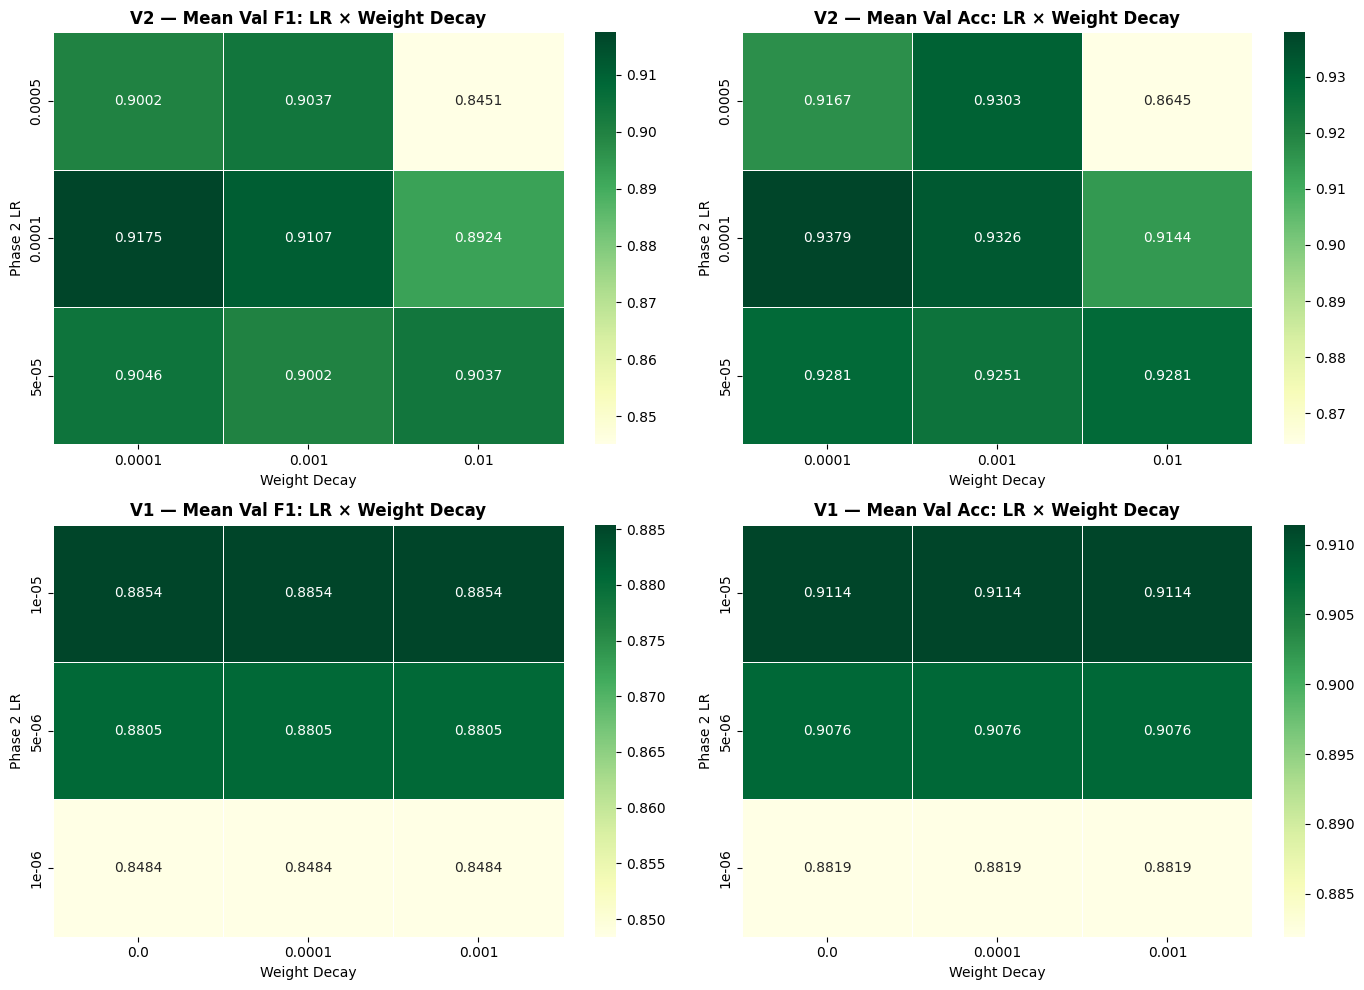

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\grid-search-results\grid_search_heatmaps.svg


[WindowsPath('C:/Users/markm/Workspace/ms-machine-learning-diagnosis/data/experiments/grid-search-results/grid_search_heatmaps.svg')]

In [13]:
def plot_heatmaps(summary_df, version, axes_row):
    """Plot F1 and accuracy heatmaps for one search version."""
    sub = summary_df[summary_df["version"] == version].copy()
    lr2_vals = sorted(sub["lr_phase2"].unique(), reverse=True)
    wd_vals  = sorted(sub["weight_decay"].unique())

    pivot_f1  = sub.pivot(index="lr_phase2", columns="weight_decay", values="mean_val_f1")
    pivot_acc = sub.pivot(index="lr_phase2", columns="weight_decay", values="mean_val_acc")
    pivot_f1  = pivot_f1.reindex(index=lr2_vals, columns=wd_vals)
    pivot_acc = pivot_acc.reindex(index=lr2_vals, columns=wd_vals)

    for pivot, ax, metric in [(pivot_f1, axes_row[0], "Mean Val F1"),
                               (pivot_acc, axes_row[1], "Mean Val Acc")]:
        sns.heatmap(pivot, ax=ax, annot=True, fmt=".4f", cmap="YlGn",
                    linewidths=0.5, cbar=True)
        ax.set_title(f"{version} — {metric}: LR × Weight Decay", fontsize=12, fontweight="bold")
        ax.set_xlabel("Weight Decay", fontsize=10)
        ax.set_ylabel("Phase 2 LR", fontsize=10)


n_versions = summary["version"].nunique()
fig, axes = plt.subplots(n_versions, 2, figsize=(14, 5 * n_versions))

if n_versions == 1:
    axes = [axes]   # keep consistent indexing

for i, version in enumerate(summary["version"].unique()):
    plot_heatmaps(summary, version, axes[i])

plt.tight_layout()
plt.show()

utils.save_fig(fig, RESULTS_DIR, "grid_search_heatmaps", formats=("svg",))